# Visualização de Dados na prática
### Desafio com Dados

---

> **Profª. Suzana Mota: Curso Técnico - Inteligência Artificial - IFNMG (Ceadi)**
>
> Aluno: Antonio Ray Martins Vieira




### Configurações

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

### Carregamento dos Dados

In [ ]:
url = 'https://raw.githubusercontent.com/suzanasvm/visualizacao_de_dados/refs/heads/main/datasets/evasao_escolar_brasil.csv'
df = pd.read_csv(url)
df.head()

,ano,regiao,taxa_evasao,nota_media_enem,renda_familiar_salario_minimo,percentual_internet,percentual_professores_com_nivel_superior,alunos_por_turma,percentual_escolas_com_laboratorio_informatica,investimento_por_aluno
0,2018,Norte,14.2,492,1.4,38,61,34,22,3820
1,2018,Nordeste,12.8,501,1.6,42,67,32,28,3950
2,2018,Centro-Oeste,8.1,532,2.3,67,82,28,51,5340
3,2018,Sudeste,6.4,548,2.9,74,89,27,63,6120
4,2018,Sul,5.9,553,3.1,78,91,26,68,6480


### Visão geral do dataset

In [ ]:
print('VISÃO GERAL DO DATASET')
print('Linhas e colunas:', df.shape)
print('Colunas:', df.columns.tolist())

VISÃO GERAL DO DATASET
Linhas e colunas: (15, 10)
Colunas: ['ano', 'regiao', 'taxa_evasao', 'nota_media_enem', 'renda_familiar_salario_minimo', 'percentual_internet', 'percentual_professores_com_nivel_superior', 'alunos_por_turma', 'percentual_escolas_com_laboratorio_informatica', 'investimento_por_aluno']


In [ ]:
# Resumo estatístico
df.describe()

,ano,taxa_evasao,nota_media_enem,renda_familiar_salario_minimo,percentual_internet,percentual_professores_com_nivel_superior,alunos_por_turma,percentual_escolas_com_laboratorio_informatica,investimento_por_aluno
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,2020.000000,10.440000,518.333333,2.133333,65.533333,79.466667,30.400000,48.533333,5048.000000
std,1.690309,3.920787,26.111483,0.678935,16.906747,11.999206,3.290679,19.111951,1116.974229
min,2018.000000,5.900000,478.000000,1.200000,38.000000,61.000000,26.000000,22.000000,3640.000000
25%,2018.000000,7.150000,494.000000,1.450000,50.500000,68.000000,28.000000,29.000000,3870.000000
50%,2020.000000,8.900000,525.000000,2.200000,72.000000,83.000000,29.000000,53.000000,5280.000000
75%,2022.000000,13.900000,540.000000,2.750000,79.000000,90.500000,33.500000,66.000000,6085.000000
max,2022.000000,17.100000,553.000000,3.100000,87.000000,93.000000,36.000000,72.000000,6480.000000


### Diagnóstico de qualidade

In [ ]:
print('DIAGNÓSTICO DE QUALIDADE')
print('\nValores ausentes por coluna:')
print(df.isnull().sum())
print('\nLinhas duplicadas:', df.duplicated().sum())

DIAGNÓSTICO DE QUALIDADE

Valores ausentes por coluna:
ano                                               0
regiao                                            0
taxa_evasao                                       0
nota_media_enem                                   0
renda_familiar_salario_minimo                     0
percentual_internet                               0
percentual_professores_com_nivel_superior         0
alunos_por_turma                                  0
percentual_escolas_com_laboratorio_informatica    0
investimento_por_aluno                            0
dtype: int64

Linhas duplicadas: 0


### Pergunta 1
**A renda familiar influencia a taxa de evasão escolar nas diferentes regiões do Brasil?**

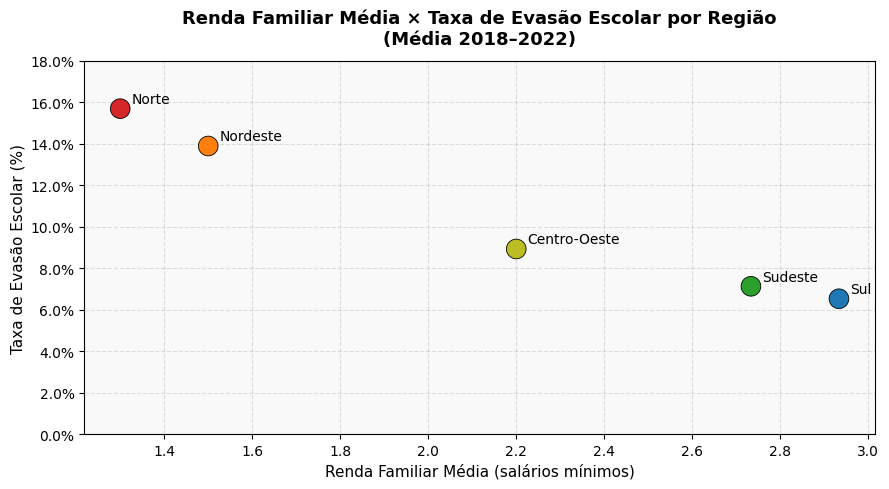

In [ ]:
# Média dos três anos por região
df_media = df.groupby('regiao')[['taxa_evasao', 'renda_familiar_salario_minimo']].mean().reset_index()
df_media = df_media.sort_values('taxa_evasao', ascending=False)

cores = {
    'Norte': '#d62728',
    'Nordeste': '#ff7f0e',
    'Centro-Oeste': '#bcbd22',
    'Sudeste': '#2ca02c',
    'Sul': '#1f77b4'
}

fig, ax = plt.subplots(figsize=(9, 5))

scatter = ax.scatter(
    df_media['renda_familiar_salario_minimo'],
    df_media['taxa_evasao'],
    c=[cores[r] for r in df_media['regiao']],
    s=200,
    edgecolors='black',
    linewidths=0.6,
    zorder=3
)

for _, row in df_media.iterrows():
    ax.annotate(
        row['regiao'],
        (row['renda_familiar_salario_minimo'], row['taxa_evasao']),
        textcoords='offset points', xytext=(8, 4),
        fontsize=10
    )

ax.set_title('Renda Familiar Média × Taxa de Evasão Escolar por Região\n(Média 2018–2022)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Renda Familiar Média (salários mínimos)', fontsize=11)
ax.set_ylabel('Taxa de Evasão Escolar (%)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('white')
ax.set_ylim(0, 18)

plt.tight_layout()
plt.savefig('grafico1_renda_evasao.png', dpi=150)
plt.show()

## Interpretação - Gráfico 1

Pelo gráfico, é possível observar que as regiões Norte e Nordeste, com menor renda familiar média (em torno de 1,3 a 1,5 salários mínimos), apresentam as maiores taxas de evasão escolar (Norte acima de 15% e Nordeste próximo de 14%). Já as regiões Sul e Sudeste, com renda média próxima a 3 salários mínimos, registram as menores taxas (abaixo de 8%).

## Pergunta 2
**Regiões com maior investimento por aluno apresentam melhores notas no ENEM?**

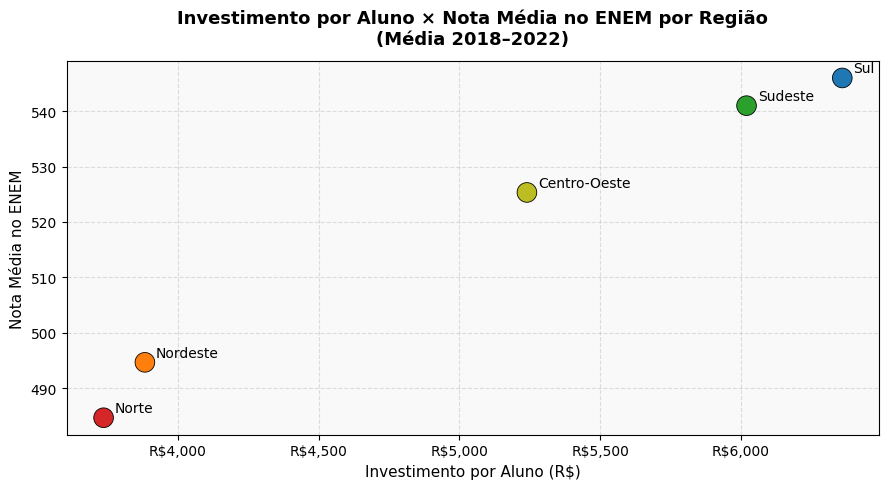

In [ ]:
# Agrupa os dados por região e calcula a média dos três anos (2018, 2020 e 2022)
df_media_d = df.groupby('regiao')[['investimento_por_aluno', 'nota_media_enem']].mean().reset_index()

cores = {
    'Norte': '#d62728',
    'Nordeste': '#ff7f0e',
    'Centro-Oeste': '#bcbd22',
    'Sudeste': '#2ca02c',
    'Sul': '#1f77b4'
}

fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(
    df_media_d['investimento_por_aluno'],
    df_media_d['nota_media_enem'],
    c=[cores[r] for r in df_media_d['regiao']],
    s=200, edgecolors='black', linewidths=0.6, zorder=3
)

for _, row in df_media_d.iterrows():
    ax.annotate(
        row['regiao'],
        (row['investimento_por_aluno'], row['nota_media_enem']),
        textcoords='offset points', xytext=(8, 4), fontsize=10
    )

ax.set_title('Investimento por Aluno × Nota Média no ENEM por Região\n(Média 2018–2022)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Investimento por Aluno (R$)', fontsize=11)
ax.set_ylabel('Nota Média no ENEM', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

## Interpretação - Gráfico 2

O gráfico mostra que regiões com maior investimento por aluno tendem a
apresentar melhores notas no ENEM. Sul e Sudeste, com investimento médio
acima de R\$6.000, atingem notas acima de 540, enquanto Norte e Nordeste,
com investimento abaixo de R\$4.000, ficam abaixo de 500.

## Conclusão

Analisando os dois gráficos em conjunto, percebe-se um padrão consistente: as regiões Norte e Nordeste acumulam desvantagens em múltiplos fatores: menor renda familiar, menor investimento por aluno e, consequentemente, maior evasão e pior desempenho no ENEM. Já as regiões Sul e Sudeste, com maior renda e maior investimento público na educação, apresentam os melhores resultados nos dois indicadores. Isso sugere que a evasão escolar e o baixo desempenho acadêmico não são causados por um único fator isolado, mas por um conjunto de condições socioeconômicas e de infraestrutura que se reforçam mutuamente, e que demandam políticas públicas integradas para serem superadas. O Centro-Oeste
ocupa posição intermediária nos dois indicadores, reforçando a consistência
da relação observada.